##KIDNEY STONE CYST TUMOR DETECTION USING TRANSFER LEARNING

## Common Dependencies For Convolution Neural Network and Transfer Learning

In [ ]:
!pip install opendatasets
import opendatasets as od
import os
"""username:chaithanya
account number:34002846"""
dataset_path = "ct-kidney-dataset-normal-cyst-tumor66j-and-stone"
if not os.path.exists(dataset_path):
    od.download("https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/data")
else:
    print(f"Dataset already exists at {dataset_path}. Skipping download.")

Skipping, found downloaded files in "./ct-kidney-dataset-normal-cyst-tumor-and-stone" (use force=True to force download)


#### Plot code for loss curves

In [ ]:
import matplotlib.pyplot as plt # Ensure plt is imported here if not globally
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.

  Args:
    history: TensorFlow model History object (see: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History)
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']
  epochs = range(len(history.history['loss']))
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

In [ ]:
import numpy as np # Added import for numpy
import matplotlib.pyplot as plt # Added import for pyplot
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix # Added imports
import seaborn as sns # Added import for seaborn

def evaluate(actual, predictions):
  pre = []
  for i in predictions:
    pre.append(np.argmax(i))
  accuracy = (pre == actual).sum() / actual.shape[0]
  print(f'Accuracy: {accuracy}')
  precision, recall, f1_score, _ = precision_recall_fscore_support(actual, pre, average='macro')
  print(f'Precision: {precision}')
  print(f'Recall: {recall}')
  print(f'F1_score: {f1_score}')
  fig, ax = plt.subplots(figsize=(10,10))
  conf_mat = confusion_matrix(actual, pre)
  sns.heatmap(conf_mat, annot=True, fmt='.0f', cmap="YlGnBu", xticklabels=diseases_labels, yticklabels=diseases_labels).set_title('Confusion Matrix Heat map')
  plt.show()

## Split Dataset code

In [ ]:
!pip install split-folders

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow import keras # Ensure keras is imported if used directly like keras.metrics

import matplotlib.pyplot as plt
import numpy as np
from skimage import transform
!pip install split-folders # Ensure split-folders is installed
import splitfolders

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

import seaborn as sns

In [ ]:
!pip install split-folders # Ensure split-folders is installed at the top for reliability
!pip install opendatasets
import os
import shutil # Import shutil for removing directories
import splitfolders
import opendatasets as od # Added this import to ensure opendatasets is available

# Dataset paths
dataset_base_path = "/content/ct-kidney-dataset-normal-cyst-tumor-and-stone"
# Corrected: The actual class folders (Cyst, Normal, Stone, Tumor) are located
# within the second nested folder with the same name.
final_data_path = os.path.join(
    dataset_base_path,
    "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", # First nested folder after base
    "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"  # This second nested folder contains the actual classes
)

# Check if the dataset base path exists, and re-download if not.
if not os.path.exists(final_data_path):
    print(f"Dataset not found at {final_data_path}. Attempting to re-download...")
    # The download function will prompt for Kaggle credentials if not already configured
    od.download("https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/data")
    print("Dataset re-downloaded.")
    # Verify path after re-download
    if not os.path.exists(final_data_path):
        raise FileNotFoundError(
            f"Dataset still not found at expected path after re-download: {final_data_path}\n"
            f"Please check the extracted dataset structure."
        )

input_folder = final_data_path

print("Using input folder for splitfolders:", input_folder)

# Clean up previous split if it exists, to ensure fresh split with correct path
if os.path.exists('./dataset'):
    print("Removing existing './dataset' directory for a clean split.")
    shutil.rmtree('./dataset')

# Split dataset into Train (90%) and Validation (10%)
splitfolders.ratio(
    input=input_folder,
    output="./dataset",
    seed=7,
    ratio=(0.9, 0.1)
)

print("Dataset split completed successfully!")

Using input folder for splitfolders: /content/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone


Copying files: 12446 files [00:13, 946.90 files/s] 

Dataset split completed successfully!


In [ ]:
train_datagen = ImageDataGenerator(rescale=1/255)
valid_datagen = ImageDataGenerator(rescale=1/255)

train_dataset = train_datagen.flow_from_directory('./dataset/train',
                                                  target_size=(200, 200),
                                                  color_mode='rgb',
                                                  class_mode='categorical',
                                                  batch_size=100,
                                                  )

valid_dataset = valid_datagen.flow_from_directory('./dataset/val',
                                                  target_size=(200, 200),
                                                  class_mode='categorical',
                                                  batch_size=100,
                                                  color_mode='rgb',
                                                  shuffle=False
                                                  )

Found 11200 images belonging to 4 classes.
Found 1246 images belonging to 4 classes.


In [ ]:
diseases_labels = []
for key, value in train_dataset.class_indices.items():
   diseases_labels.append(key)
print(diseases_labels)

['Cyst', 'Normal', 'Stone', 'Tumor']


## CNN Method

In [ ]:
model = Sequential()
model.add(Conv2D(4, (15, 15), activation='tanh', input_shape=train_dataset.image_shape))
model.add(MaxPooling2D(8))
model.add(MaxPooling2D(4))
model.add(Flatten())
model.add(Dense(8, activation='tanh'))
model.add(Dense(train_dataset.num_classes, activation='softmax')) # Dynamically set output classes
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 186, 186, 4)    │         2,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,548 (13.86 KB)

 Trainable params: 3,548 (13.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

METRICS = [
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')]

model.compile(optimizer = "rmsprop", loss='categorical_crossentropy', metrics = METRICS)

In [ ]:
Info = model.fit(
                 train_dataset,
                 validation_data=valid_dataset,
                 epochs=8)

Epoch 1/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 60s 469ms/step - accuracy: 0.6194 - loss: 0.9974 - precision: 0.7617 - recall: 0.4313 - val_accuracy: 0.6830 - val_loss: 0.8635 - val_precision: 0.7772 - val_recall: 0.5570
Epoch 2/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 461ms/step - accuracy: 0.7263 - loss: 0.7825 - precision: 0.7954 - recall: 0.6023 - val_accuracy: 0.7480 - val_loss: 0.7296 - val_precision: 0.8113 - val_recall: 0.6244
Epoch 3/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 50s 448ms/step - accuracy: 0.7794 - loss: 0.6640 - precision: 0.8418 - recall: 0.6655 - val_accuracy: 0.7825 - val_loss: 0.6374 - val_precision: 0.8427 - val_recall: 0.6750
Epoch 4/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 50s 442ms/step - accuracy: 0.8140 - loss: 0.5752 - precision: 0.8651 - recall: 0.7338 - val_accuracy: 0.8106 - val_loss: 0.5578 - val_precision: 0.8703 - val_recall: 0.7376
Epoch 5/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 51s 457ms/step - accuracy: 0.8396 - loss: 0.5074 - precision: 0.8827 - recall: 0.7796 - val_accuracy: 0.8467 - va

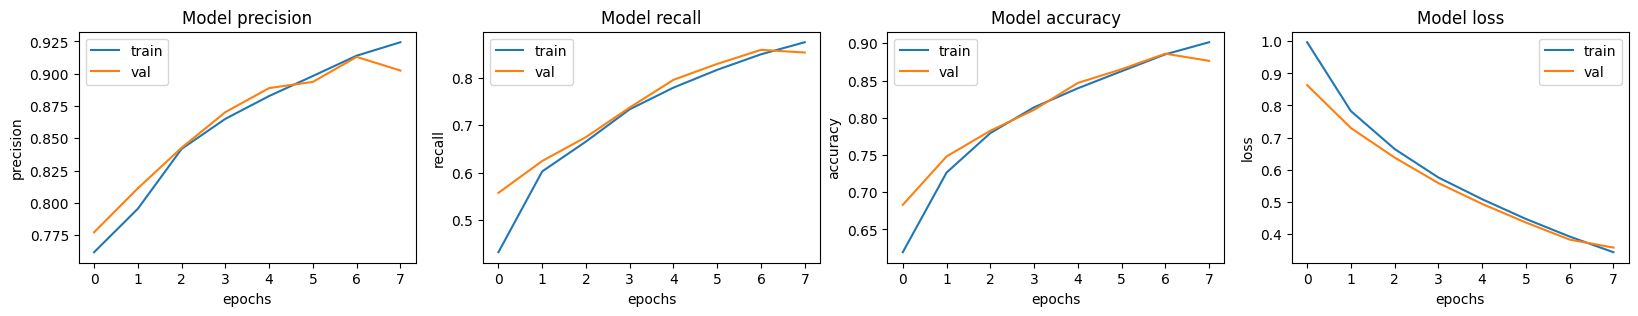

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 4, figsize=(20, 3))
ax = ax.ravel()
for i, met in enumerate(['precision', 'recall', 'accuracy', 'loss']):
    ax[i].plot(Info.history[met])
    ax[i].plot(Info.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

In [ ]:
predictions = model.predict(valid_dataset)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step


In [ ]:
def evaluate(actual, predictions):
  pre = []
  for i in predictions:
    pre.append(np.argmax(i))
  accuracy = (pre == actual).sum() / actual.shape[0]
  print(f'Accuracy: {accuracy}')
  precision, recall, f1_score, _ = precision_recall_fscore_support(actual, pre, average='macro')
  print(f'Precision: {precision}')
  print(f'Recall: {recall}')
  print(f'F1_score: {f1_score}')
  fig, ax = plt.subplots(figsize=(10,10))
  conf_mat = confusion_matrix(actual, pre)
  sns.heatmap(conf_mat, annot=True, fmt='.0f', cmap="YlGnBu", xticklabels=diseases_labels, yticklabels=diseases_labels).set_title('Confusion Matrix Heat map')
  plt.show()

Accuracy: 0.9301765650080257
Precision: 0.9294916047038507
Recall: 0.8802209525504899
F1_score: 0.8982203049813271


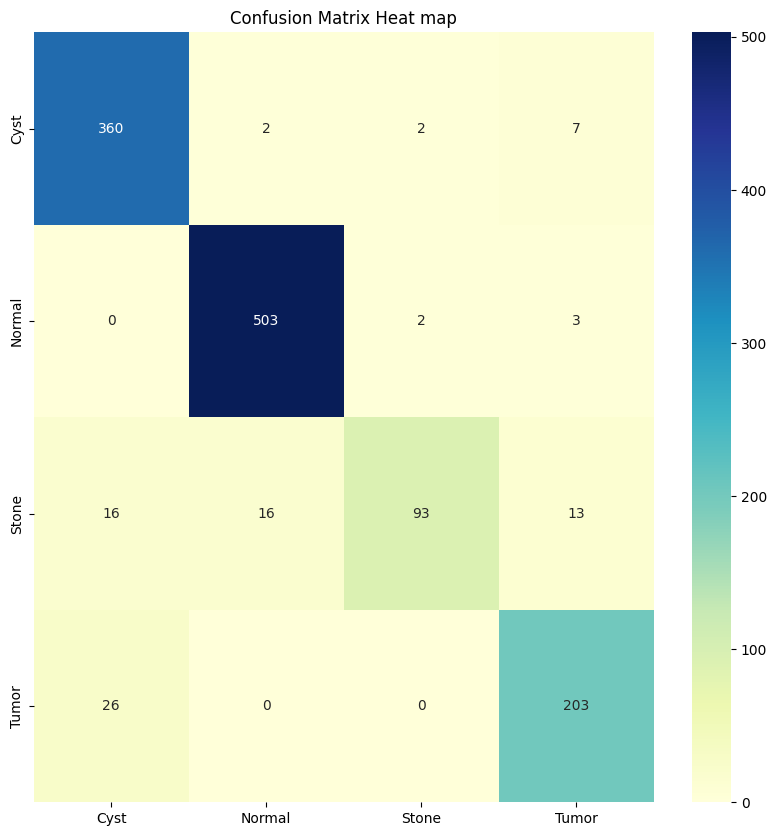

In [ ]:
evaluate(valid_dataset.classes,predictions)

In [ ]:
model.evaluate(valid_dataset)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.9302 - loss: 0.2284 - precision: 0.9459 - recall: 0.9117


[0.2284194380044937,
 0.9301765561103821,
 0.9458784461021423,
 0.9117174744606018]

Original image shape/size:  (512, 512, 3)


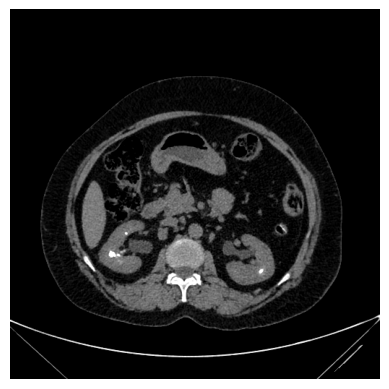

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
prediction Output =  1
Predicted as:  Normal


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
image_path = '/content/dataset/train/Stone/Stone- (396).jpg' # Path adjusted based on successful split
img = mpimg.imread(image_path)
print("Original image shape/size: ", img.shape)
plt.imshow(img)
plt.axis('off')
plt.show()
def classify_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    pred = np.argmax(preds)
    print("prediction Output = ",pred)
    print("Predicted as: ", diseases_labels[pred])
classify_image(image_path)

In [ ]:
diseases_labels

['Cyst', 'Normal', 'Stone', 'Tumor']

## Transfer Learning Method

### Inception V3 Model

In [ ]:
import numpy as np
import pandas as pd
import os
import shutil
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from keras import applications
from keras import Sequential, layers
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten
from keras.optimizers import Adam
import tensorflow_hub as hub
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from keras.applications.inception_v3 import InceptionV3
base_model = InceptionV3(include_top=False)
base_model.trainable = False
inputs = layers.Input(shape=( 200, 200, 3), name="input_layer")
x = base_model(inputs)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
outputs = tf.keras.layers.Dense(4, activation="softmax", name="output_layer")(x)
inception = keras.Model(inputs, outputs)
inception.summary()
inception.compile(loss = 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4),
                metrics = ['accuracy'])
inception_history = inception.fit(train_dataset,
                            steps_per_epoch = len(train_dataset),
                            epochs = 10,
                            validation_data = valid_dataset,
                            validation_steps = len(valid_dataset))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 4, 4, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,335,852 (85.20 MB)

 Trainable params: 533,068 (2.03 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 91s 617ms/step - accuracy: 0.6847 - loss: 0.8604 - val_accuracy: 0.8218 - val_loss: 0.5294
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 461ms/step - accuracy: 0.8645 - loss: 0.4028 - val_accuracy: 0.8788 - val_loss: 0.3389
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 468ms/step - accuracy: 0.9200 - loss: 0.2456 - val_accuracy: 0.9021 - val_loss: 0.2642
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 51s 458ms/step - accuracy: 0.9552 - loss: 0.1554 - val_accuracy: 0.9615 - val_loss: 0.1373
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 82s 463ms/step - accuracy: 0.9798 - loss: 0.0915 - val_accuracy: 0.9751 - val_loss: 0.0845
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 468ms/step - accuracy: 0.9883 - loss: 0.0609 - val_accuracy: 0.9872 - val_loss: 0.0650
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 465ms/step - accuracy: 0.9948 - loss: 0.0405 - val_accuracy: 0.9912 - val_loss: 0.0467
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 466ms/step - accuracy: 0.9963 - loss: 0

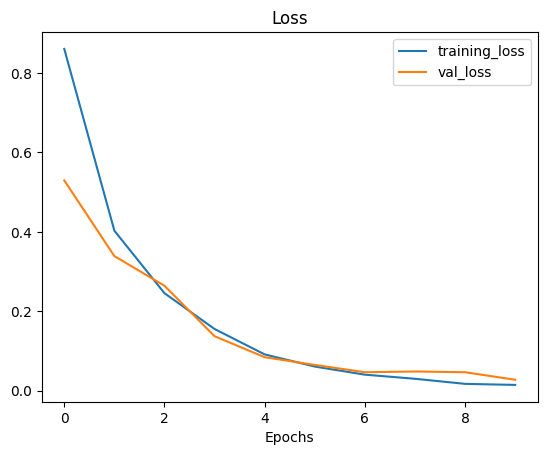

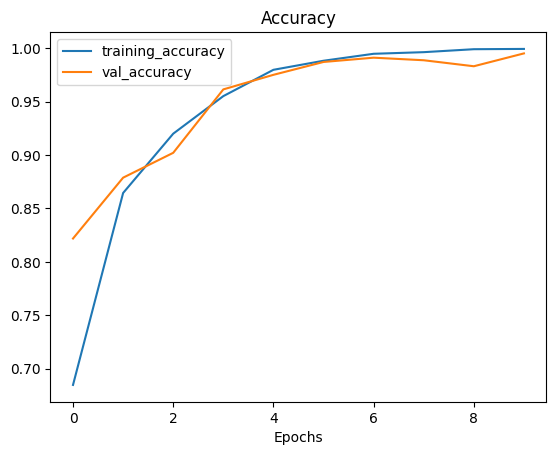

In [ ]:
plot_loss_curves(inception_history)

In [ ]:
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_1 False
1 conv2d_1 False
2 batch_normalization False
3 activation False
4 conv2d_2 False
5 batch_normalization_1 False
6 activation_1 False
7 conv2d_3 False
8 batch_normalization_2 False
9 activation_2 False
10 max_pooling2d_2 False
11 conv2d_4 False
12 batch_normalization_3 False
13 activation_3 False
14 conv2d_5 False
15 batch_normalization_4 False
16 activation_4 False
17 max_pooling2d_3 False
18 conv2d_9 False
19 batch_normalization_8 False
20 activation_8 False
21 conv2d_7 False
22 conv2d_10 False
23 batch_normalization_6 False
24 batch_normalization_9 False
25 activation_6 False
26 activation_9 False
27 average_pooling2d False
28 conv2d_6 False
29 conv2d_8 False
30 conv2d_11 False
31 conv2d_12 False
32 batch_normalization_5 False
33 batch_normalization_7 False
34 batch_normalization_10 False
35 batch_normalization_11 False
36 activation_5 False
37 activation_7 False
38 activation_10 False
39 activation_11 False
40 mixed0 False
41 conv2d_16 False
42 batch_normalizati

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-61]:
  layer.trainable = False
inception.compile(loss = 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-5),
                metrics = ['accuracy'])

In [ ]:
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)
print(len(inception.trainable_variables))

0 input_layer_1 False
1 conv2d_1 False
2 batch_normalization False
3 activation False
4 conv2d_2 False
5 batch_normalization_1 False
6 activation_1 False
7 conv2d_3 False
8 batch_normalization_2 False
9 activation_2 False
10 max_pooling2d_2 False
11 conv2d_4 False
12 batch_normalization_3 False
13 activation_3 False
14 conv2d_5 False
15 batch_normalization_4 False
16 activation_4 False
17 max_pooling2d_3 False
18 conv2d_9 False
19 batch_normalization_8 False
20 activation_8 False
21 conv2d_7 False
22 conv2d_10 False
23 batch_normalization_6 False
24 batch_normalization_9 False
25 activation_6 False
26 activation_9 False
27 average_pooling2d False
28 conv2d_6 False
29 conv2d_8 False
30 conv2d_11 False
31 conv2d_12 False
32 batch_normalization_5 False
33 batch_normalization_7 False
34 batch_normalization_10 False
35 batch_normalization_11 False
36 activation_5 False
37 activation_7 False
38 activation_10 False
39 activation_11 False
40 mixed0 False
41 conv2d_16 False
42 batch_normalizati

In [ ]:
inception.compile(loss = 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-5),
                metrics = ['accuracy'])
inception_history = inception.fit(train_dataset,
                            steps_per_epoch = len(train_dataset),
                            epochs = 20,
                            validation_data = valid_dataset,
                            initial_epoch = inception_history.epoch[-1],
                            validation_steps = len(valid_dataset))

Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 96s 599ms/step - accuracy: 0.9496 - loss: 0.1679 - val_accuracy: 0.9888 - val_loss: 0.0359
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 487ms/step - accuracy: 0.9990 - loss: 0.0199 - val_accuracy: 0.9968 - val_loss: 0.0164
Epoch 12/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 479ms/step - accuracy: 0.9999 - loss: 0.0092 - val_accuracy: 0.9968 - val_loss: 0.0125
Epoch 13/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 480ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.9984 - val_loss: 0.0087
Epoch 14/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 82s 484ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9976 - val_loss: 0.0072
Epoch 15/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 477ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9984 - val_loss: 0.0063
Epoch 16/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9984 - val_loss: 0.0053
Epoch 17/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 489ms/step - accuracy: 1.0000 -

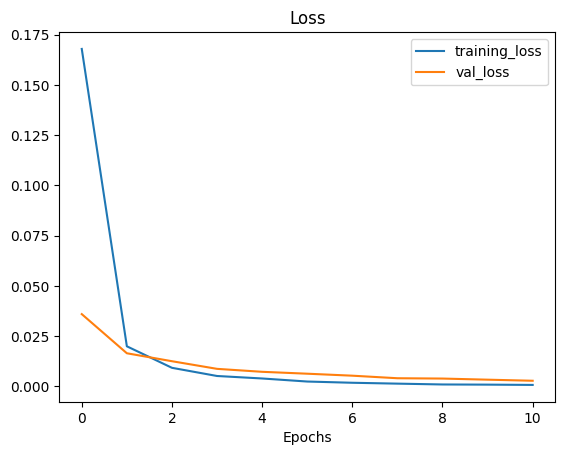

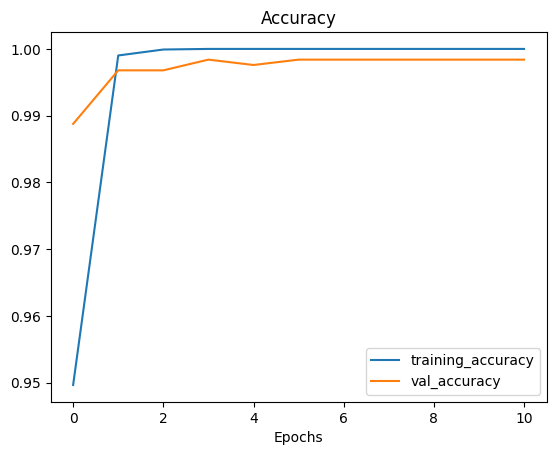

In [ ]:
plot_loss_curves(inception_history)

In [ ]:
predictions_inception = inception.predict(valid_dataset)

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 916ms/step


Accuracy: 0.9983948635634029
Precision: 0.9976972466615415
Recall: 0.997514551349662
F1_score: 0.997605202838491


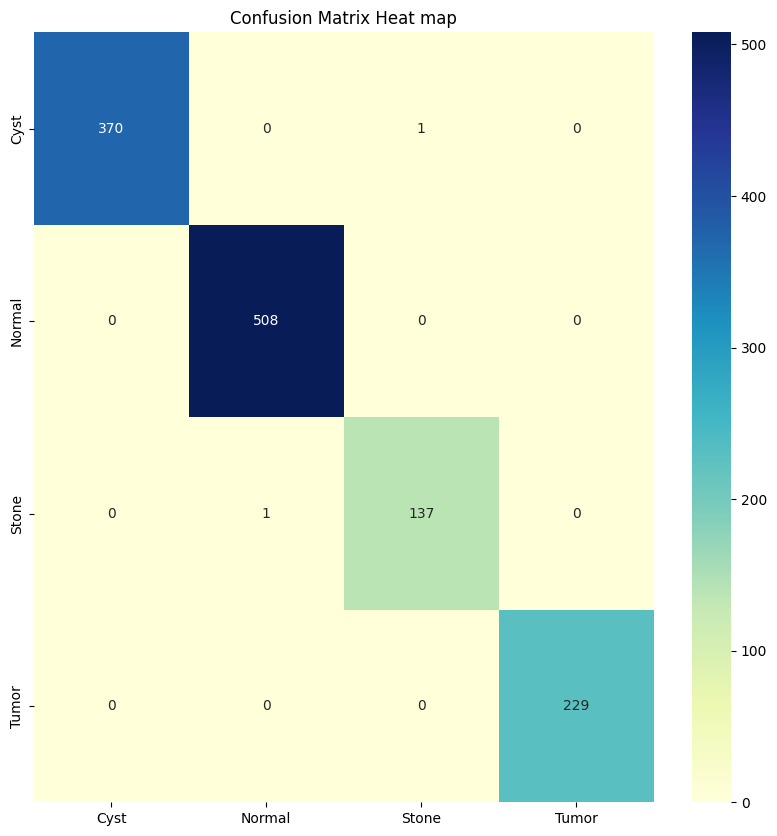

Specificity: 0.99730456
Sensitivity: 1.0


In [ ]:
evaluate(valid_dataset.classes, predictions_inception)
import tensorflow as tf
def specificity(y_true, y_pred):
    y_pred_indices = tf.argmax(y_pred, axis=1)
    true_negatives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, 0), tf.equal(y_pred_indices, 0)), tf.float32))
    actual_negatives = tf.reduce_sum(tf.cast(tf.equal(y_true, 0), tf.float32))
    return true_negatives / (actual_negatives + tf.keras.backend.epsilon())
def sensitivity(y_true, y_pred):
    y_pred_indices = tf.argmax(y_pred, axis=1)
    true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, 1), tf.equal(y_pred_indices, 1)), tf.float32))
    actual_positives = tf.reduce_sum(tf.cast(tf.equal(y_true, 1), tf.float32))
    return true_positives / (actual_positives + tf.keras.backend.epsilon())
spec = specificity(valid_dataset.classes, predictions_inception)
sens = sensitivity(valid_dataset.classes, predictions_inception)
print("Specificity:", spec.numpy())
print("Sensitivity:", sens.numpy())

## For displaying a single Image

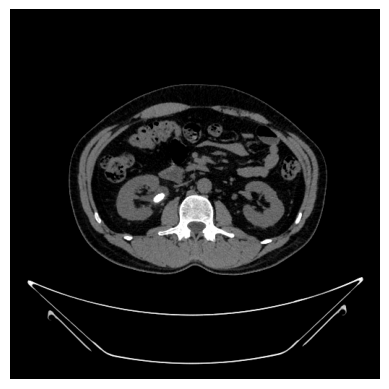

image shape: (512, 512, 3)
image dtype: uint8


In [ ]:
image_path = "/content/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone/Stone- (10).jpg"
label = 0
image = mpimg.imread(image_path)
plt.imshow(image)
plt.axis('off')
plt.show()
print("image shape:", image.shape)
print("image dtype:", image.dtype)

#For Display Random images

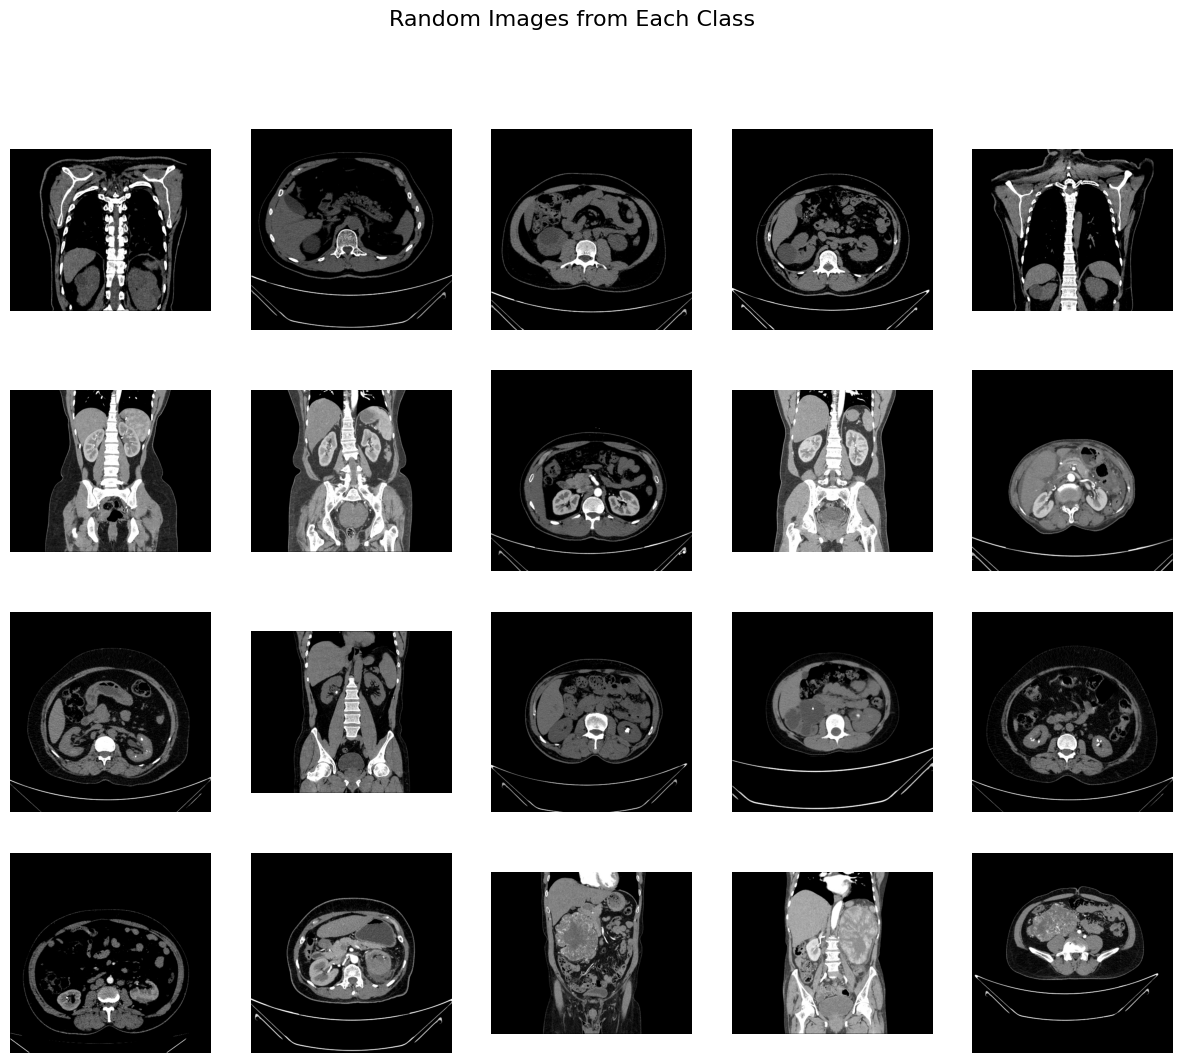

In [ ]:
import random
main_directory = "/content/dataset/train"
classes = ['Cyst', 'Normal', 'Stone', 'Tumor']
fig, axs = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Random Images from Each Class', fontsize=16)
for i, class_name in enumerate(classes):
    class_directory = os.path.join(main_directory, class_name)
    image_files = os.listdir(class_directory)
    random_images = random.sample(image_files, 5)
    for j, image_file in enumerate(random_images):
        image_path = os.path.join(class_directory, image_file)
        image = mpimg.imread(image_path)
        axs[i, j].imshow(image, cmap='gray')
        axs[i, j].axis('off')

plt.show()

#Image Detection Result

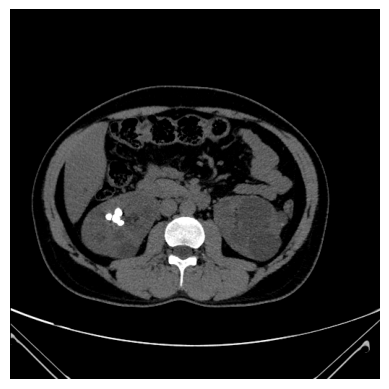

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
prediction Output =  0
Predicted as:  Cyst


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
image_path = '/content/dataset/train/Cyst/Cyst- (1155).jpg'
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()
def classify_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    pred = np.argmax(preds)
    print("prediction Output = ",pred)
    print("Predicted as: ", diseases_labels[pred])
classify_image(image_path)

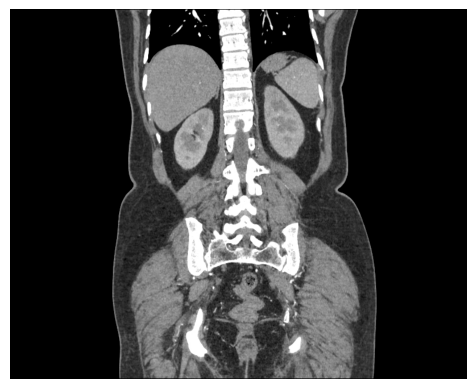

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
prediction Output =  1
Predicted as:  Normal


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
image_path = '/content/dataset/train/Normal/Normal- (1723).jpg'
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()
def classify_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    pred = np.argmax(preds)
    print("prediction Output = ",pred)
    print("Predicted as: ", diseases_labels[pred])
classify_image(image_path)

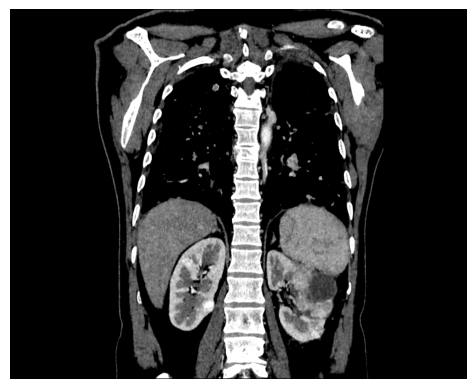

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
prediction Output =  0
Predicted as:  Cyst


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
image_path = '/content/dataset/val/Tumor/Tumor- (1251).jpg'
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()
def classify_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    pred = np.argmax(preds)
    print("prediction Output = ",pred)
    print("Predicted as: ", diseases_labels[pred])
classify_image(image_path)

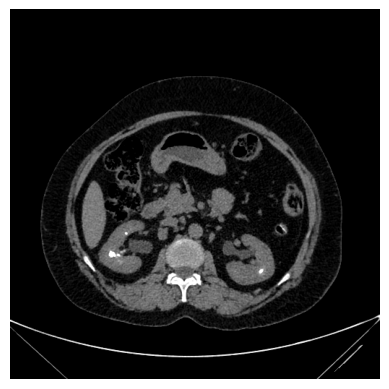

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
prediction Output =  1
Predicted as:  Normal


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
image_path = '/content/dataset/train/Stone/Stone- (396).jpg'
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()
def classify_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)
    pred = np.argmax(preds)
    print("prediction Output = ",pred)
    print("Predicted as: ", diseases_labels[pred])
classify_image(image_path)

This notebook is designed to build a model that can detect kidney stones, cysts, tumors, and normal kidneys from CT scan images using deep learning. The process involves:

Setting up the environment and downloading the dataset: The necessary libraries are installed, and the dataset containing CT scan images is downloaded from Kaggle.
Defining helper functions: Functions are defined to plot loss curves and evaluate the model's performance (accuracy, precision, recall, F1-score, and confusion matrix).
Splitting the dataset: The dataset is split into training and validation sets to train and evaluate the models.
Building and training a Convolutional Neural Network (CNN): A custom CNN model is built from scratch, compiled, and trained on the training data.
Evaluating the CNN model: The performance of the trained CNN model is evaluated using the validation data.
Implementing Transfer Learning with InceptionV3: A pre-trained InceptionV3 model is loaded, and new layers are added for the specific task of kidney image classification. The model is then fine-tuned.
Evaluating the Transfer Learning model: The performance of the InceptionV3-based model is evaluated.
Visualizing results: The loss curves and evaluation metrics are plotted to understand the training process and model performance.
Testing with individual images: Finally, the trained models are used to classify individual images to see how they perform on unseen data.


What is a CT Scan?

CT stands for Computed Tomography. It's a medical imaging technique that uses a series of X-ray images taken from different angles around your body. A computer then processes these images to create cross-sectional slices (like slices of bread) of the bones, blood vessels, and soft tissues inside your body. These slices are much more detailed than traditional X-rays and can show a clear picture of internal organs and structures.

In the context of this dataset, the CT scans are focused on the kidneys to identify abnormalities like cysts, tumors, and stones.

What types of images are you using now?

The dataset you've downloaded contains CT scan images of kidneys, categorized into four classes:

Normal: These are images of healthy kidneys without any apparent issues.
Cyst: These images show kidneys with cysts, which are fluid-filled sacs that can develop in the kidneys.
Tumor: These images show kidneys with tumors, which are abnormal growths of tissue.
Stone: These images show kidneys with kidney stones, which are hard deposits made of minerals and salts that form inside the kidneys.
The images themselves are likely grayscale (black and white) representations of the CT slices. The different shades of gray represent different tissue densities. For example, dense bone appears white, while air appears black. The variations in gray help medical professionals (and in this case, your model) distinguish between different structures and identify abnormalities.

The process of getting and using the data involves a few key steps:

1. Downloading the dataset from Kaggle:

The code cell with the ID FYfSqrOxjLNP is responsible for downloading the dataset.
It uses the opendatasets library, which simplifies the process of downloading datasets from Kaggle.
!pip install opendatasets installs the library if you don't have it.
import opendatasets as od imports the library so you can use its functions.
dataset_path = "ct-kidney-dataset-normal-cyst-tumor-and-stone" defines the name for the dataset's folder.
The if not os.path.exists(dataset_path): block checks if the dataset has already been downloaded. This is a good practice to avoid downloading it multiple times.
od.download("https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/data") is the core command that downloads the dataset from the specified Kaggle URL. When you run this, it will prompt you to enter your Kaggle username and API key (which you did in the output you provided). This is how opendatasets authenticates with Kaggle to download the data.
The dataset is downloaded as a zip file and then automatically extracted into a folder with the name ct-kidney-dataset-normal-cyst-tumor-and-stone in your Colab environment.
2. Splitting the dataset:

The code cell with the ID -h6D8f_7qT19 uses the splitfolders library to divide the dataset into training and validation sets.
!pip install split-folders installs the necessary library.
import splitfolders imports the library.
splitfolders.ratio(...) is the function that performs the split.
The first argument /content/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone is the path to the main folder containing all the image subfolders (Cyst, Normal, Stone, Tumor).
output="./dataset" specifies that the split datasets will be saved in a new folder named dataset in the current directory.
seed=7 sets a random seed for reproducibility, meaning you'll get the same split every time you run the code with this seed.
ratio=(0.9, 0.1) defines the split ratio: 90% of the data goes to the training set and 10% goes to the validation set.
After this step, you will have a new dataset folder with train and val subfolders, and inside those, the Cyst, Normal, Stone, and Tumor subfolders containing the images for each set.
Training Set: This is all your homework. You learn the material by studying these problems over and over.

Validation Set: These are your practice exams. You take them during the semester to see how you're doing. Based on your score, you might change your study strategy (e.g., "I need to focus more on this chapter"). This is like tuning your model.

Test Set: This is the final, official exam. You only take it once at the very end. The score is your final grade and shows how well you'll perform on questions you've truly never seen before. You can't go back and change your study habits after seeing the final exam.
3. Managing and manipulating the dataset with ImageDataGenerator:

The code cell with the ID TCx5_MeGqaWV uses ImageDataGenerator from TensorFlow/Keras to manage and load the images for training and validation.
train_datagen = ImageDataGenerator(rescale=1/255) creates an ImageDataGenerator for the training data. The rescale=1/255 argument is a crucial manipulation step: it scales the pixel values of the images from the original 0-255 range to a 0-1 range. This is a common and important preprocessing step for neural networks.
valid_datagen = ImageDataGenerator(rescale=1/255) creates a similar generator for the validation data.
train_dataset = train_datagen.flow_from_directory(...) creates a DirectoryIterator (which acts like a dataset) that reads images from the ./dataset/train folder.
target_size=(200, 200) resizes all images to 200x200 pixels, which is necessary to have a consistent input size for the neural network.
color_mode='rgb' specifies that the images are treated as color images (although they appear grayscale, they have three channels).
class_mode='categorical' indicates that the labels are one-hot encoded (e.g., [1, 0, 0, 0] for the first class).
batch_size=100 specifies that the images will be loaded in batches of 100. This is efficient for training.
valid_dataset = valid_datagen.flow_from_directory(...) does the same for the validation data from the ./dataset/val folder. shuffle=False is set for the validation set because you don't need to shuffle the data during evaluation.
How the dataset "works" now:

The train_dataset and valid_dataset objects are not just static lists of images. They are generators. This means they don't load all the images into memory at once. Instead, they load images in batches as needed during the training and evaluation process. This is very important for large datasets like this one, as it prevents memory issues.

When you train a model using model.fit(train_dataset, ...) or evaluate it using model.evaluate(valid_dataset), the model will request batches of images and their corresponding labels from these generators. The generators handle reading the image files from the specified directories, applying the preprocessing steps (like resizing and rescaling), and providing the data to the model.

In essence, the ImageDataGenerator is a powerful tool for efficiently handling and preprocessing image datasets, making them ready for use with deep learning models.